In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt


filename = 'phishing_websites.csv'
dataset = pd.read_csv(filename).to_numpy()
print(type(dataset))
print(np.shape(dataset))

X = dataset[:,0:30]
y = dataset[:,-1]

print(type(X))
print(np.shape(X))
print(np.shape(y))

print(X)
print(y)

<class 'numpy.ndarray'>
(11054, 31)
<class 'numpy.ndarray'>
(11054, 30)
(11054,)
[[ 1  1  1 ...  1  1  1]
 [ 1  0  1 ...  1  0 -1]
 [ 1  0  1 ...  1 -1  1]
 ...
 [ 1 -1  1 ...  1  0  1]
 [-1 -1  1 ...  1  1  1]
 [-1 -1  1 ... -1  1 -1]]
[-1 -1 -1 ... -1 -1 -1]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


In [9]:
dt_basic = DecisionTreeClassifier(random_state=42)
dt_basic_scores = cross_val_score(dt_basic, X_train, y_train, cv=cv, scoring='accuracy')
print(f"Basic DT-CV Accuracy: {dt_basic_scores.mean():.4f} (+/- {dt_basic_scores.std()*2:.4f})")

Basic DT-CV Accuracy: 0.9635 (+/- 0.0121)


In [10]:
depth_values = [3, 5, 10, None]
for depth in depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='accuracy')
    print(f"max_depth={depth}: {scores.mean():.4f}")


max_depth=3: 0.9060
max_depth=5: 0.9178
max_depth=10: 0.9467
max_depth=None: 0.9635


In [11]:
split_values = [2, 5, 10, 20]
for split in split_values:
    dt = DecisionTreeClassifier(min_samples_split=split, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='accuracy')
    print(f"min_samples_split={split}: {scores.mean():.4f}")

min_samples_split=2: 0.9635
min_samples_split=5: 0.9586
min_samples_split=10: 0.9526
min_samples_split=20: 0.9507


In [12]:
leaf_values = [1, 5, 10, 20, 50]
for leaf in leaf_values:
    dt = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='accuracy')
    print(f"min_samples_leaf={leaf}: {scores.mean():.4f}")

min_samples_leaf=1: 0.9635
min_samples_leaf=5: 0.9430
min_samples_leaf=10: 0.9409
min_samples_leaf=20: 0.9334
min_samples_leaf=50: 0.9274


In [13]:
param_grid = {
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV accuracy: 0.9594


In [15]:
print(f"Decision Tree Best CV Accuracy: {grid_search.best_score_:.4f}")
print("(Previous best SVM: ~0.9685, k-NN: ~0.97)")

Decision Tree Best CV Accuracy: 0.9594
(Previous best SVM: ~0.9685, k-NN: ~0.97)


In [ ]:
best_dt = grid_search.best_estimator_
best_dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [17]:
y_pred = best_dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
fscore = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F-Score: {fscore:.4f}")

Accuracy: 0.9602
Precision: 0.9674
Recall: 0.9611
F-Score: 0.9643


In [18]:
y_proba = best_dt.predict_proba(X_test)
y_scores = y_proba[:, 1]

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")


AUC: 0.9732


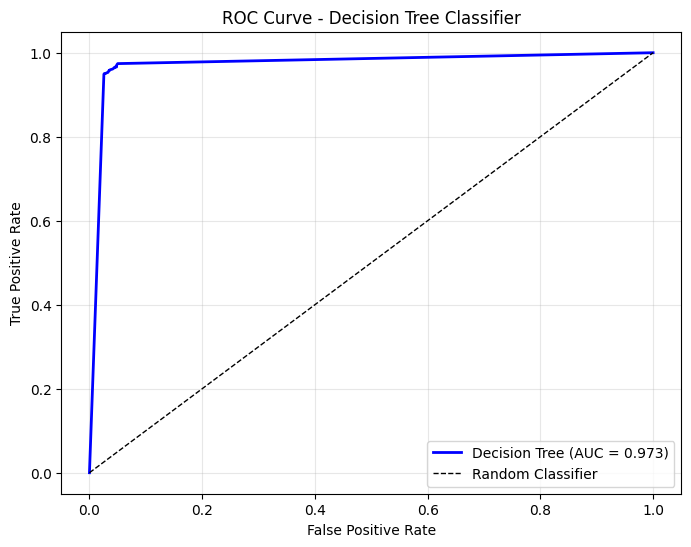

In [20]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Decision Tree (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree Classifier')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()